<a href="https://colab.research.google.com/github/endrage07/Capstone_InstaCart_MarketBasket/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================
# STEP 3: DATA PREPROCESSING & EDA
# Instacart Market Basket Analysis
# ============================

!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ----------------------------
# 3.1 Load data
# ----------------------------
path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

orders = pd.read_csv(f"{path}/orders.csv")
order_products_prior = pd.read_csv(f"{path}/order_products__prior.csv")
order_products_train = pd.read_csv(f"{path}/order_products__train.csv")
products = pd.read_csv(f"{path}/products.csv")
aisles = pd.read_csv(f"{path}/aisles.csv")
departments = pd.read_csv(f"{path}/departments.csv")

print("orders:", orders.shape)
print("order_products_prior:", order_products_prior.shape)
print("order_products_train:", order_products_train.shape)
print("products:", products.shape)
print("aisles:", aisles.shape)
print("departments:", departments.shape)

Using Colab cache for faster access to the 'instacart-market-basket-analysis' dataset.
orders: (3421083, 7)
order_products_prior: (32434489, 4)
order_products_train: (1384617, 4)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


In [ ]:
# ----------------------------
# 3.2 Quick schema inspection
# ----------------------------

def quick_overview(df, name):
    print(f"\n=== {name} HEAD ===")
    display(df.head())
    print(f"\n=== {name} INFO ===")
    print(df.info())
    print(f"\n=== {name} DESCRIBE (numeric) ===")
    display(df.describe())

quick_overview(orders, "orders")
quick_overview(order_products_prior, "order_products_prior")
quick_overview(products, "products")


=== orders HEAD ===


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0



=== orders INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB
None

=== orders DESCRIBE (numeric) ===


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01



=== order_products_prior HEAD ===


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0



=== order_products_prior INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB
None

=== order_products_prior DESCRIBE (numeric) ===


,order_id,product_id,add_to_cart_order,reordered
count,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07
mean,1.710749e+06,2.557634e+04,8.351076e+00,5.896975e-01
std,9.873007e+05,1.409669e+04,7.126671e+00,4.918886e-01
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.559430e+05,1.353000e+04,3.000000e+00,0.000000e+00
50%,1.711048e+06,2.525600e+04,6.000000e+00,1.000000e+00
75%,2.565514e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00



=== products HEAD ===


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



=== products INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

=== products DESCRIBE (numeric) ===


,product_id,aisle_id,department_id
count,49688.000000,49688.000000,49688.000000
mean,24844.500000,67.769582,11.728687
std,14343.834425,38.316162,5.850410
min,1.000000,1.000000,1.000000
25%,12422.750000,35.000000,7.000000
50%,24844.500000,69.000000,13.000000
75%,37266.250000,100.000000,17.000000
max,49688.000000,134.000000,21.000000


In [ ]:
# ----------------------------
# 3.3 Missing values report + handling
# ----------------------------

def missing_values_report(df, name):
    mv = df.isna().sum()
    mv = mv[mv > 0]
    if mv.empty:
        print(f"\n=== Missing Values Report: {name} ===")
        print("No missing values.")
        return mv
    mv = mv.to_frame("n_missing")
    mv["pct_missing"] = mv["n_missing"] / len(df) * 100
    print(f"\n=== Missing Values Report: {name} ===")
    display(mv)
    return mv

orders_mv = missing_values_report(orders, "orders")
order_products_prior_mv = missing_values_report(order_products_prior, "order_products_prior")
products_mv = missing_values_report(products, "products")


=== Missing Values Report: orders ===


,n_missing,pct_missing
days_since_prior_order,206209,6.027594



=== Missing Values Report: order_products_prior ===
No missing values.

=== Missing Values Report: products ===
No missing values.


In [ ]:
# Interpretation of missing values:
# - In orders, 'days_since_prior_order' is missing for each user's first order.
#   This is expected behaviour (no "prior" order).
# Strategy:
#   1. Impute missing days_since_prior_order with 0.
#   2. Create a flag 'is_first_order' to retain information content.

orders["is_first_order"] = orders["days_since_prior_order"].isna().astype(int)
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

# Re-check
missing_values_report(orders, "orders (after handling)")


=== Missing Values Report: orders (after handling) ===
No missing values.


,0


In [ ]:
# ----------------------------
# 3.4 Duplicates check & handling
# ----------------------------

def duplicates_report(df, name):
    n_dups = df.duplicated().sum()
    print(f"{name}: {n_dups} duplicate full rows")
    return n_dups

duplicates_report(orders, "orders")
duplicates_report(order_products_prior, "order_products_prior")
duplicates_report(products, "products")

# If there are any exact duplicates in transactional tables, drop them:
order_products_prior = order_products_prior.drop_duplicates()
orders = orders.drop_duplicates()
products = products.drop_duplicates()

orders: 0 duplicate full rows
order_products_prior: 0 duplicate full rows
products: 0 duplicate full rows


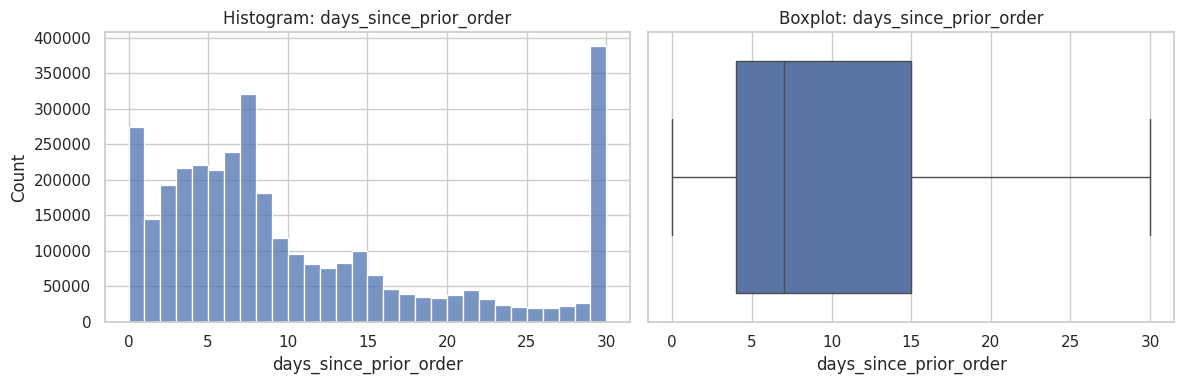

In [ ]:
# ----------------------------
# 3.5 Outlier inspection (example: days_since_prior_order)
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(orders["days_since_prior_order"], bins=30, kde=False, ax=axes[0])
axes[0].set_title("Histogram: days_since_prior_order")

sns.boxplot(x=orders["days_since_prior_order"], ax=axes[1])
axes[1].set_title("Boxplot: days_since_prior_order")

plt.tight_layout()
plt.show()

# Domain choice:
#   - Very large gaps (e.g. > 30 days) may reflect long inactivity.
#   - Instead of dropping, we cap (winsorize) them to 30 days to reduce skew
#     but keep information that these are "long intervals".

CAP_DAYS = 30
orders["days_since_prior_order_capped"] = orders["days_since_prior_order"].clip(upper=CAP_DAYS)

In [ ]:
# ----------------------------
# 3.6 Merge prior orders with product metadata (base table for EDA)
# ----------------------------

# Focus on 'prior' set for EDA (historic behaviour)
orders_prior = orders[orders["eval_set"] == "prior"]

prior_merged = (
    order_products_prior
    .merge(orders_prior, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

print("prior_merged:", prior_merged.shape)
display(prior_merged.head())

prior_merged: (32434489, 17)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order,days_since_prior_order_capped,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,0,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,0,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,0,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,0,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,0,8.0,Natural Sweetener,17,13,baking ingredients,pantry


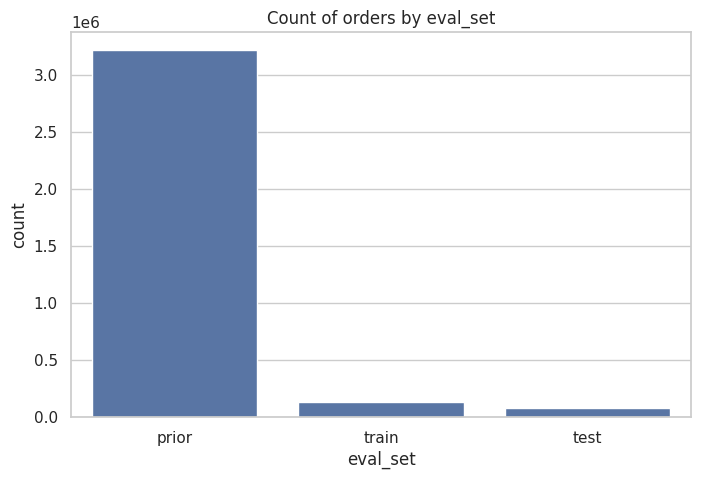

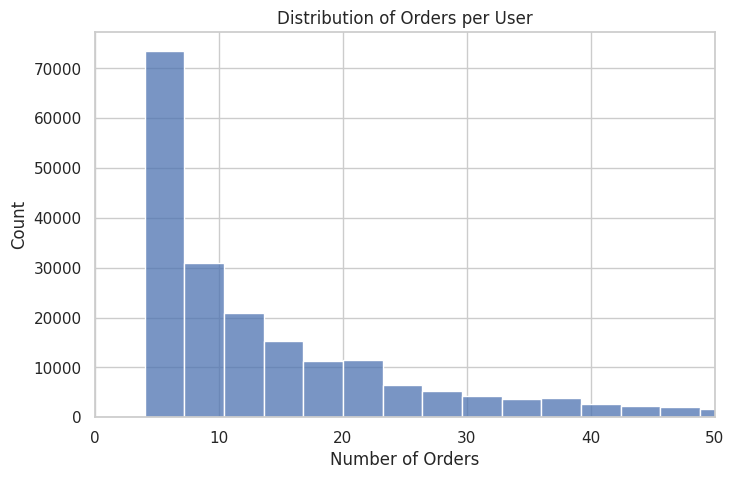

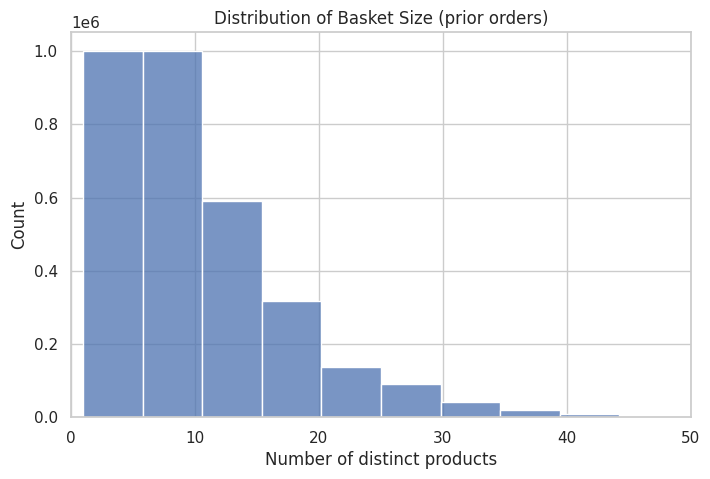

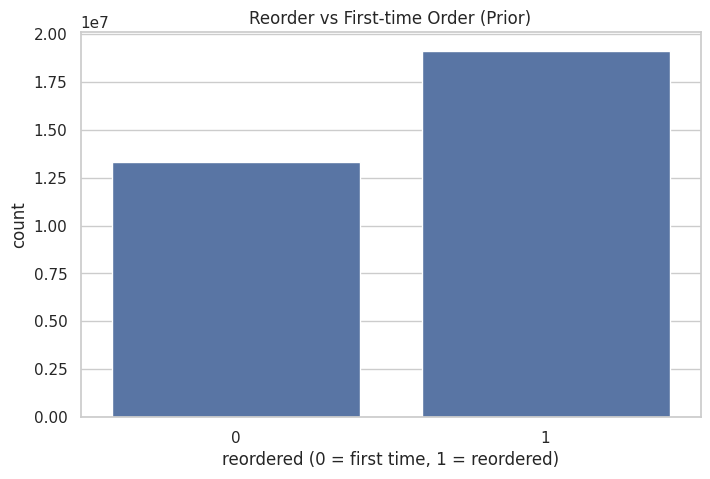

In [ ]:
# ----------------------------
# 3.7 Univariate EDA
# ----------------------------

# Distribution of orders by evaluation set
sns.countplot(x="eval_set", data=orders)
plt.title("Count of orders by eval_set")
plt.show()

# Orders per user
orders_per_user = orders.groupby("user_id")["order_id"].nunique()
sns.histplot(orders_per_user, bins=30)
plt.title("Distribution of Orders per User")
plt.xlabel("Number of Orders")
plt.xlim(0, 50)  # cap view for readability
plt.show()

# Products per order (basket size) using prior_merged
basket_size = prior_merged.groupby("order_id")["product_id"].nunique()
sns.histplot(basket_size, bins=30)
plt.title("Distribution of Basket Size (prior orders)")
plt.xlabel("Number of distinct products")
plt.xlim(0, 50)
plt.show()

# Reorder flag distribution
sns.countplot(x="reordered", data=order_products_prior)
plt.title("Reorder vs First-time Order (Prior)")
plt.xlabel("reordered (0 = first time, 1 = reordered)")
plt.show()

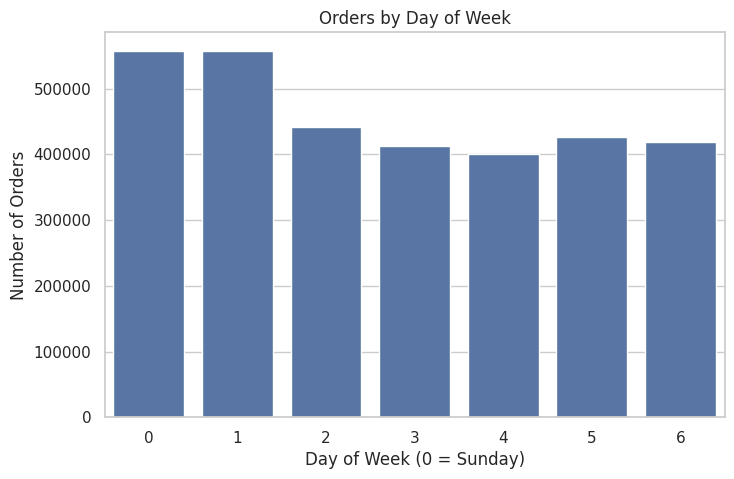

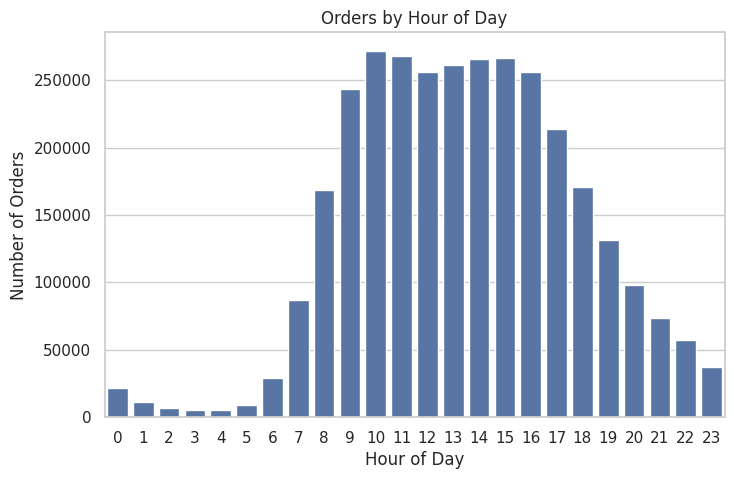

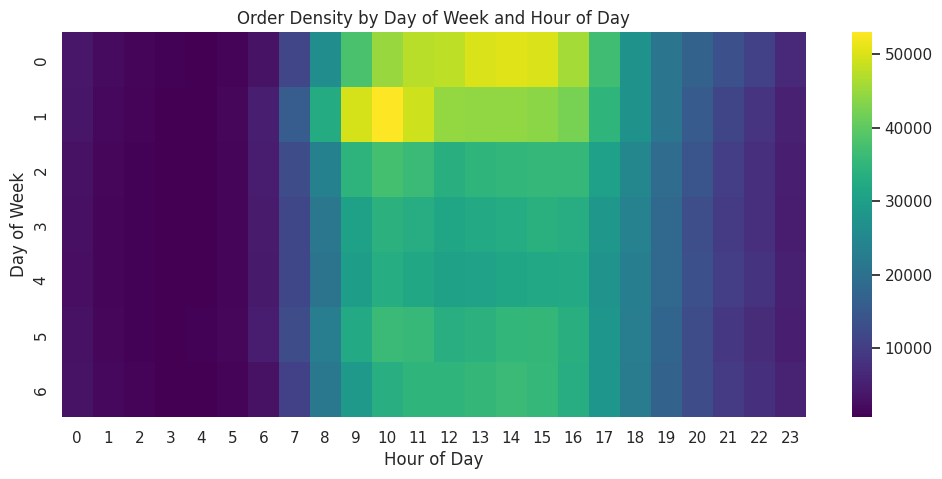

In [ ]:
# ----------------------------
# 3.8 Time-based EDA (order_dow, order_hour_of_day)
# ----------------------------

# Orders by day of week
dow_counts = orders_prior["order_dow"].value_counts().sort_index()
sns.barplot(x=dow_counts.index, y=dow_counts.values)
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week (0 = Sunday)")
plt.ylabel("Number of Orders")
plt.show()

# Orders by hour of day
hour_counts = orders_prior["order_hour_of_day"].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

# Heatmap: order_dow vs order_hour_of_day
dow_hour_pivot = (
    orders_prior
    .groupby(["order_dow", "order_hour_of_day"])["order_id"]
    .count()
    .reset_index()
    .pivot(index="order_dow", columns="order_hour_of_day", values="order_id")
)

plt.figure(figsize=(12, 5))
sns.heatmap(dow_hour_pivot, cmap="viridis")
plt.title("Order Density by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

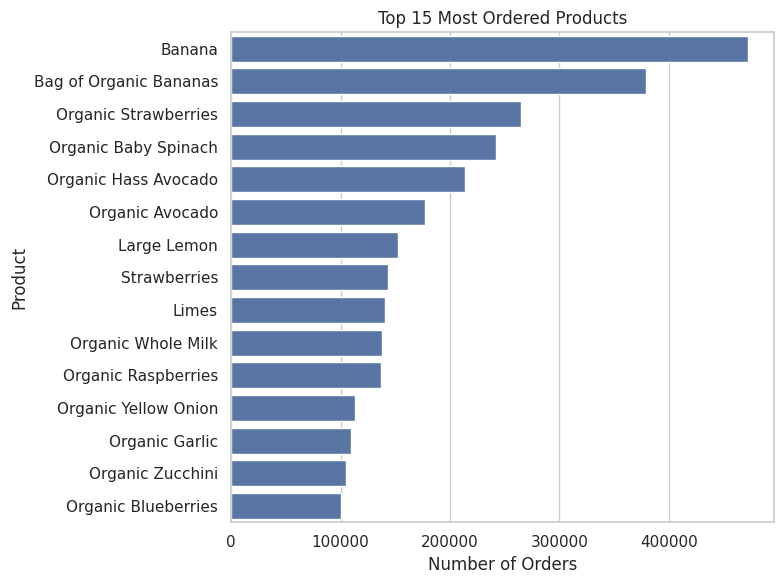

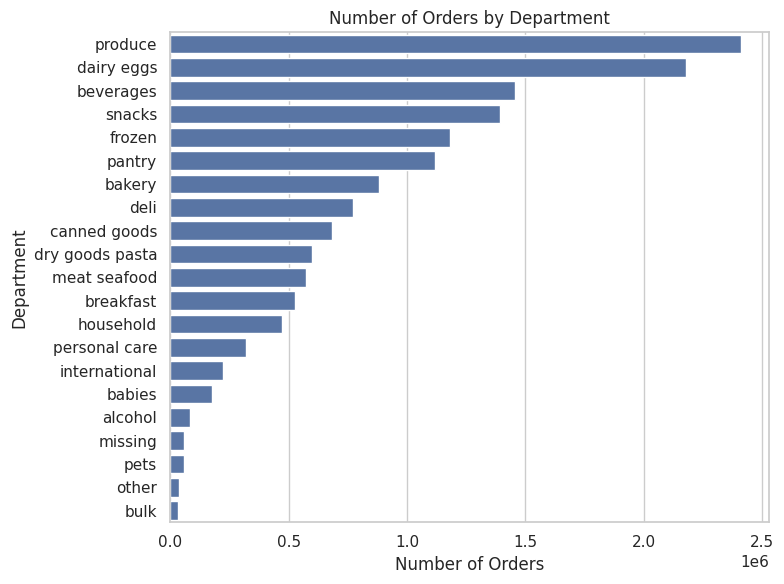

In [ ]:
# ----------------------------
# 3.9 Product-level EDA (top products, aisles, departments)
# ----------------------------

# Top 15 most frequently ordered products
top_products = (
    prior_merged
    .groupby("product_id")
    .agg(order_count=("order_id", "size"))
    .reset_index()
    .merge(products[["product_id", "product_name"]], on="product_id", how="left")
    .sort_values("order_count", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_products, x="order_count", y="product_name")
plt.title("Top 15 Most Ordered Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# Orders by department
dept_counts = (
    prior_merged
    .groupby("department")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=dept_counts.values, y=dept_counts.index)
plt.title("Number of Orders by Department")
plt.xlabel("Number of Orders")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

Using numeric columns: ['order_dow', 'order_hour_of_day', 'days_since_prior_order', 'days_since_prior_order_capped', 'is_first_order']


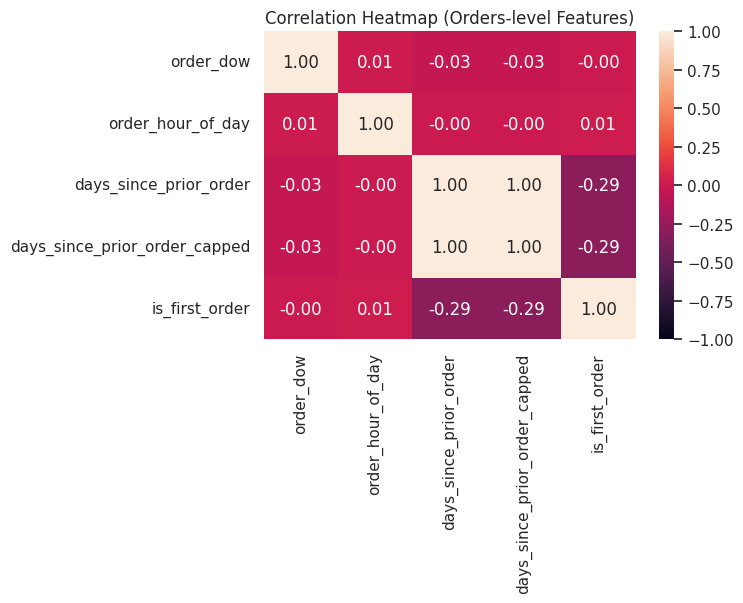

In [ ]:
# ----------------------------
# 3.10 Correlation analysis (orders-level numeric features)
# ----------------------------

# Ensure is_first_order exists on the full orders table
if "is_first_order" not in orders.columns:
    # If missing, reconstruct it based on days_since_prior_order == 0
    # (first orders had NaN originally, which we filled with 0 earlier)
    orders["is_first_order"] = (orders["days_since_prior_order"] == 0).astype(int)

# Make sure orders_prior is rebuilt from the latest version of orders
orders_prior = orders[orders["eval_set"] == "prior"].copy()

numeric_cols = [
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "days_since_prior_order_capped",
    "is_first_order",
]

# Only keep columns that actually exist (defensive programming)
numeric_cols_existing = [c for c in numeric_cols if c in orders_prior.columns]
print("Using numeric columns:", numeric_cols_existing)

corr = orders_prior[numeric_cols_existing].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Orders-level Features)")
plt.show()

**Feature Engineering**

In [ ]:
# ----------------------------
# 3.11 Product-level features
# ----------------------------

product_features = (
    prior_merged
    .groupby("product_id")
    .agg(
        prod_total_orders=("order_id", "size"),
        prod_distinct_users=("user_id", "nunique"),
        prod_reorder_rate=("reordered", "mean"),
        prod_mean_add_to_cart_order=("add_to_cart_order", "mean")
    )
    .reset_index()
    .merge(products[["product_id", "product_name", "aisle_id", "department_id"]], on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

# Popularity normalized per user
product_features["prod_orders_per_user"] = (
    product_features["prod_total_orders"] / product_features["prod_distinct_users"]
)

display(product_features.head())

,product_id,prod_total_orders,prod_distinct_users,prod_reorder_rate,prod_mean_add_to_cart_order,product_name,aisle_id,department_id,aisle,department,prod_orders_per_user
0,1,1852,716,0.613391,5.801836,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks,2.586592
1,2,90,78,0.133333,9.888889,All-Seasons Salt,104,13,spices seasonings,pantry,1.153846
2,3,277,74,0.732852,6.415162,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages,3.743243
3,4,329,182,0.446809,9.507599,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen,1.807692
4,5,15,6,0.600000,6.466667,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry,2.500000


In [ ]:
# ----------------------------
# 3.12 User-level features
# ----------------------------

# Basket size per order
basket_size_per_order = (
    prior_merged
    .groupby(["user_id", "order_id"])["product_id"]
    .size()
    .reset_index(name="basket_size")
)

user_basket_stats = (
    basket_size_per_order
    .groupby("user_id")["basket_size"]
    .agg(
        user_mean_basket_size="mean",
        user_max_basket_size="max"
    )
)

# Orders-level stats aggregated to user
user_order_stats = (
    orders_prior
    .groupby("user_id")
    .agg(
        user_total_orders=("order_id", "nunique"),
        user_max_order_number=("order_number", "max"),
        user_mean_days_between_orders=("days_since_prior_order", "mean"),
        user_first_order_indicator=("is_first_order", "max")  # almost always 1 at least once
    )
)

# Product diversity and reorder tendency
user_product_stats = (
    prior_merged
    .groupby("user_id")
    .agg(
        user_distinct_products=("product_id", "nunique"),
        user_reorder_ratio=("reordered", "mean")
    )
)

user_features = (
    user_order_stats
    .join(user_basket_stats, how="left")
    .join(user_product_stats, how="left")
    .reset_index()
)

display(user_features.head())

,user_id,user_total_orders,user_max_order_number,user_mean_days_between_orders,user_first_order_indicator,user_mean_basket_size,user_max_basket_size,user_distinct_products,user_reorder_ratio
0,1,10,10,17.600000,1,5.900000,9,18,0.694915
1,2,14,14,14.142857,1,13.928571,26,102,0.476923
2,3,12,12,11.083333,1,7.333333,11,33,0.625000
3,4,5,5,11.000000,1,3.600000,7,17,0.055556
4,5,4,4,10.000000,1,9.250000,12,23,0.378378


In [ ]:
# ----------------------------
# 3.13 User–Product interaction features
# (captures personal affinity to a given product)
# ----------------------------

user_product_features = (
    prior_merged
    .groupby(["user_id", "product_id"])
    .agg(
        up_order_count=("order_id", "size"),                  # how many times user bought this product
        up_last_order_number=("order_number", "max"),         # recency in user's sequence
        up_mean_add_to_cart_order=("add_to_cart_order", "mean")
    )
    .reset_index()
)

# Recency feature: relative to the user's maximum order_number
user_max_order = (
    orders_prior.groupby("user_id")["order_number"].max().rename("user_global_max_order")
)

user_product_features = (
    user_product_features
    .merge(user_max_order, on="user_id", how="left")
)

user_product_features["up_recency"] = (
    user_product_features["user_global_max_order"] - user_product_features["up_last_order_number"]
)

display(user_product_features.head())

,user_id,product_id,up_order_count,up_last_order_number,up_mean_add_to_cart_order,user_global_max_order,up_recency
0,1,196,10,10,1.400000,10,0
1,1,10258,9,10,3.333333,10,0
2,1,10326,1,5,5.000000,10,5
3,1,12427,10,10,3.300000,10,0
4,1,13032,3,10,6.333333,10,0


**Feature Selection & Dimensionality Reduction**

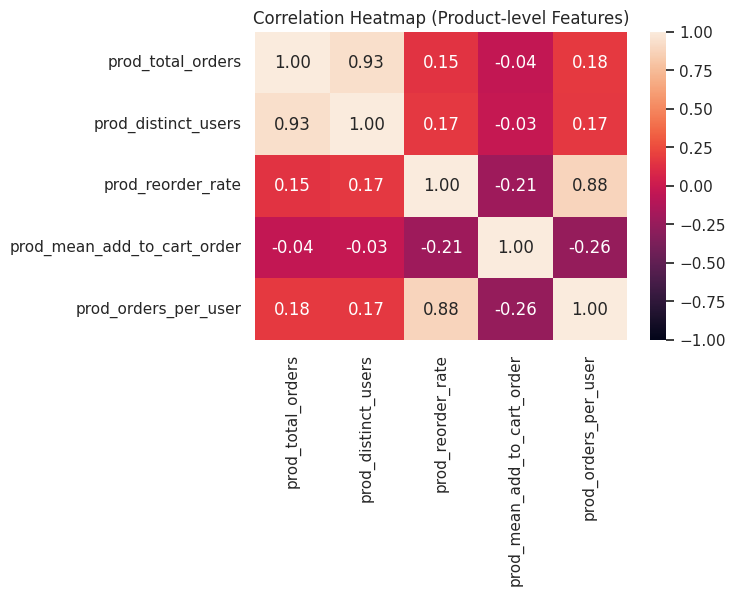

Highly correlated features to drop: ['prod_distinct_users']
Selected product feature columns: ['prod_total_orders', 'prod_reorder_rate', 'prod_mean_add_to_cart_order', 'prod_orders_per_user']


In [ ]:
# ----------------------------
# 3.14 Feature selection via correlation (product-level)
# ----------------------------

# Select numeric product features
prod_num_cols = [
    "prod_total_orders",
    "prod_distinct_users",
    "prod_reorder_rate",
    "prod_mean_add_to_cart_order",
    "prod_orders_per_user",
]

prod_num_df = product_features[prod_num_cols].copy()

# Correlation matrix
prod_corr = prod_num_df.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(prod_corr, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Product-level Features)")
plt.show()

# Simple rule: if correlation > 0.9, drop one of the pair.
# (Here we implement a generic approach.)
corr_matrix = prod_num_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Highly correlated features to drop:", to_drop)

prod_selected_cols = [c for c in prod_num_cols if c not in to_drop]
print("Selected product feature columns:", prod_selected_cols)

Explained variance ratio by components: [0.51085849 0.24117037]


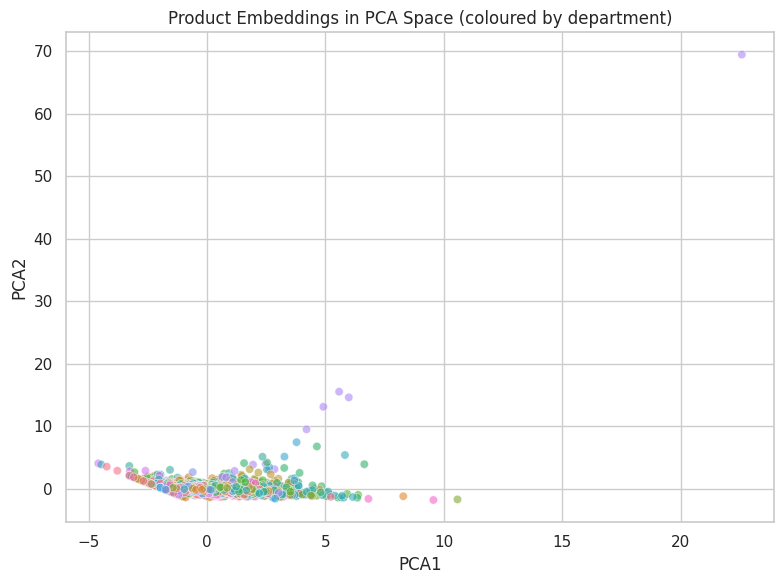

In [ ]:
# ----------------------------
# 3.15 Dimensionality reduction via PCA (product-level)
# ----------------------------

# Standardize selected numeric features
scaler = StandardScaler()
prod_scaled = scaler.fit_transform(product_features[prod_selected_cols])

# PCA to 2 dimensions for visualisation
pca = PCA(n_components=2, random_state=42)
prod_pca = pca.fit_transform(prod_scaled)

product_features["pca1"] = prod_pca[:, 0]
product_features["pca2"] = prod_pca[:, 1]

print("Explained variance ratio by components:", pca.explained_variance_ratio_)

# Visualize products in 2D PCA space, coloured by department (optional)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=product_features.sample(n=min(5000, len(product_features)), random_state=42),
    x="pca1", y="pca2", hue="department", legend=False, alpha=0.6
)
plt.title("Product Embeddings in PCA Space (coloured by department)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

**Modelling & Evaluation**

In [ ]:
# ============================
# STEP 4: MODELLING & EVALUATION
# Task: Predict whether a product in a train order is reordered (binary classification)
# ============================

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

In [ ]:
# ----------------------------
# 4.1 Build training table
# ----------------------------

# Keep only train orders with user_id
orders_train = orders[orders["eval_set"] == "train"][["order_id", "user_id"]].copy()

# Base: order_products_train + user_id
train_base = (
    order_products_train
    .merge(orders_train, on="order_id", how="left")
)

print("train_base shape:", train_base.shape)
display(train_base.head())

# Merge product-level features
prod_feats_for_merge = product_features[
    ["product_id"] +
    [c for c in product_features.columns if c.startswith("prod_")] +
    ["aisle_id", "department_id"]
]

train_with_prod = train_base.merge(
    prod_feats_for_merge,
    on="product_id",
    how="left"
)

# Merge user-level features
train_with_user = train_with_prod.merge(
    user_features,
    on="user_id",
    how="left"
)

# Merge user-product interaction features
train_full = train_with_user.merge(
    user_product_features[
        ["user_id", "product_id", "up_order_count", "up_mean_add_to_cart_order", "up_recency"]
    ],
    on=["user_id", "product_id"],
    how="left"
)

print("train_full shape:", train_full.shape)
display(train_full.head())

train_base shape: (1384617, 5)


,order_id,product_id,add_to_cart_order,reordered,user_id
0,1,49302,1,1,112108
1,1,11109,2,1,112108
2,1,10246,3,0,112108
3,1,49683,4,0,112108
4,1,43633,5,1,112108


train_full shape: (1384617, 23)


,order_id,product_id,add_to_cart_order,reordered,user_id,prod_total_orders,prod_distinct_users,prod_reorder_rate,prod_mean_add_to_cart_order,prod_orders_per_user,...,user_max_order_number,user_mean_days_between_orders,user_first_order_indicator,user_mean_basket_size,user_max_basket_size,user_distinct_products,user_reorder_ratio,up_order_count,up_mean_add_to_cart_order,up_recency
0,1,49302,1,1,112108,163.0,62.0,0.619632,6.392638,2.629032,...,3,7.333333,1,7.0,8,12,0.428571,2.0,2.5,1.0
1,1,11109,2,1,112108,4472.0,1280.0,0.713775,7.385957,3.493750,...,3,7.333333,1,7.0,8,12,0.428571,2.0,4.0,1.0
2,1,10246,3,0,112108,23826.0,11328.0,0.524553,9.608327,2.103284,...,3,7.333333,1,7.0,8,12,0.428571,NaN,NaN,NaN
3,1,49683,4,0,112108,97315.0,30002.0,0.691702,7.662467,3.243617,...,3,7.333333,1,7.0,8,12,0.428571,NaN,NaN,NaN
4,1,43633,5,1,112108,653.0,341.0,0.477795,9.248086,1.914956,...,3,7.333333,1,7.0,8,12,0.428571,2.0,3.5,0.0


In [ ]:
# ----------------------------
# 4.2 Define X, y and remove leaky features
# ----------------------------

target_col = "reordered"

# Start from full training table
data = train_full.copy()

# 1) Explicitly drop identifiers and the target
drop_cols = [
    "order_id",
    "user_id",
    "product_id",
    target_col
]

# 2) Drop obvious text/object columns
text_like_cols = ["product_name", "aisle", "department", "eval_set"]
drop_cols += [c for c in text_like_cols if c in data.columns]

data = data.drop(columns=[c for c in drop_cols if c in data.columns])

# 3) **Remove all user–product interaction features (the leaky ones)**
leaky_cols = [c for c in data.columns if c.startswith("up_")]
print("Dropping potentially leaky user-product columns:", leaky_cols)
data = data.drop(columns=leaky_cols)

# 4) Keep only numeric features and fill NaNs
feature_df = data.select_dtypes(include=[np.number]).fillna(0)

X = feature_df
y = train_full[target_col].reset_index(drop=True)

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

# Optional: sample for speed
MAX_ROWS = 500_000
if len(X) > MAX_ROWS:
    sample_idx = np.random.choice(X.index, size=MAX_ROWS, replace=False)
    X = X.loc[sample_idx].reset_index(drop=True)
    y = y.loc[sample_idx].reset_index(drop=True)
    print(f"\nSampled to {MAX_ROWS} rows for modelling.")

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Dropping potentially leaky user-product columns: ['up_order_count', 'up_mean_add_to_cart_order', 'up_recency']
Feature matrix shape: (1384617, 16)
Target distribution:
 reordered
1    0.598594
0    0.401406
Name: proportion, dtype: float64

Sampled to 500000 rows for modelling.
Final X shape: (500000, 16)
Final y shape: (500000,)


In [ ]:
# ----------------------------
# 4.3 Train-test split
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (400000, 16) Test size: (100000, 16)


In [ ]:
# ----------------------------
# 4.4 Evaluation helper
# ----------------------------

model_results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit model, compute metrics, plot confusion matrix, and store results."""
    print(f"\n=== Evaluating {name} ===")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Some models may not have predict_proba; fall back to decision_function
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        # Very rare, but handle it
        y_proba = y_pred.astype(float)

    roc_auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision:{prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Store metrics
    model_results.append({
        "model": name,
        "roc_auc": roc_auc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

    return model

Model 1: Baseline Logistic Regression


=== Evaluating Logistic Regression (baseline) ===
ROC-AUC:  0.7851
Accuracy: 0.7137
Precision:0.7891
Recall:   0.7115
F1-score: 0.7483

Classification report:
              precision    recall  f1-score   support

           0      0.625     0.717     0.668     40187
           1      0.789     0.712     0.748     59813

    accuracy                          0.714    100000
   macro avg      0.707     0.714     0.708    100000
weighted avg      0.723     0.714     0.716    100000



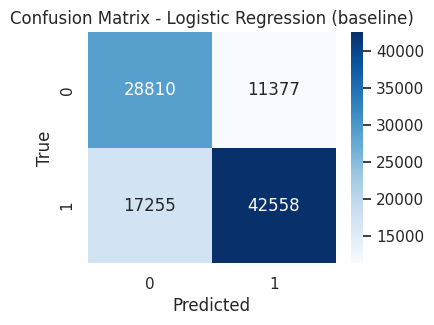

In [ ]:
# ----------------------------
# 4.5 Baseline: Logistic Regression
# ----------------------------

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False to be safe with sparse-like data
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

logreg_model = evaluate_model(
    "Logistic Regression (baseline)",
    logreg_pipeline,
    X_train, X_test, y_train, y_test
)

 Model 2 – Random Forest with RandomizedSearchCV


Using 50000 rows for RF tuning.
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Best RF params: {'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}
Best RF CV ROC-AUC: 0.779685725375274

=== Evaluating Random Forest (tuned) ===
ROC-AUC:  0.7954
Accuracy: 0.7261
Precision:0.7809
Recall:   0.7534
F1-score: 0.7669

Classification report:
              precision    recall  f1-score   support

           0      0.651     0.685     0.668     40187
           1      0.781     0.753     0.767     59813

    accuracy                          0.726    100000
   macro avg      0.716     0.719     0.717    100000
weighted avg      0.729     0.726     0.727    100000



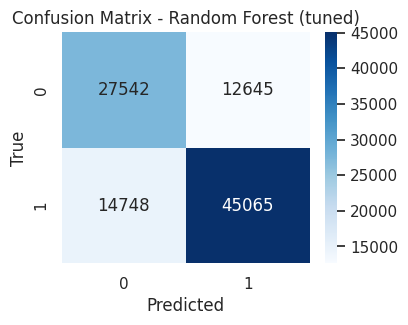

In [ ]:
# ----------------------------
# 4.6 Random Forest with light hyperparameter tuning
# ----------------------------

# Much smaller subsample for tuning
TUNE_ROWS = 50_000
if len(X_train) > TUNE_ROWS:
    tune_idx = np.random.choice(X_train.index, size=TUNE_ROWS, replace=False)
    X_tune = X_train.loc[tune_idx]
    y_tune = y_train.loc[tune_idx]
    print(f"\nUsing {TUNE_ROWS} rows for RF tuning.")
else:
    X_tune, y_tune = X_train, y_train

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

# SMALLER search space
param_dist = {
    "n_estimators": [150, 250],
    "max_depth": [10, None],
    "min_samples_split": [2, 20],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
}

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,            # down from 15
    scoring="roc_auc",
    cv=2,                # 2-fold CV for speed
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random_search.fit(X_tune, y_tune)

print("\nBest RF params:", rf_random_search.best_params_)
print("Best RF CV ROC-AUC:", rf_random_search.best_score_)

best_rf = rf_random_search.best_estimator_

rf_model = evaluate_model(
    "Random Forest (tuned)",
    best_rf,
    X_train, X_test, y_train, y_test
)

Model 3 – Gradient Boosting (light tuning)


=== Evaluating Gradient Boosting (tuned) ===
ROC-AUC:  0.7916
Accuracy: 0.7281
Precision:0.7483
Recall:   0.8218
F1-score: 0.7834

Classification report:
              precision    recall  f1-score   support

           0      0.689     0.589     0.635     40187
           1      0.748     0.822     0.783     59813

    accuracy                          0.728    100000
   macro avg      0.719     0.705     0.709    100000
weighted avg      0.725     0.728     0.724    100000



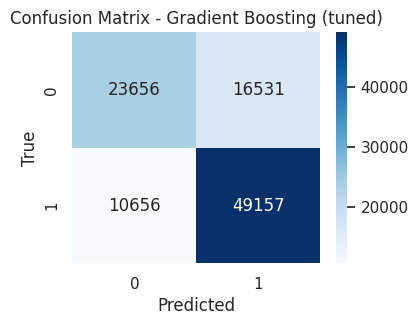

In [ ]:
# ----------------------------
# 4.7 Gradient Boosting (light tuning)
# ----------------------------

gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=150,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model = evaluate_model(
    "Gradient Boosting (tuned)",
    gb,
    X_train, X_test, y_train, y_test
)

In [ ]:
# ----------------------------
# 4.8 Compare metrics across models
# ----------------------------

results_df = pd.DataFrame(model_results).sort_values("roc_auc", ascending=False)
display(results_df)

,model,roc_auc,accuracy,precision,recall,f1
1,Random Forest (tuned),0.795388,0.72607,0.780887,0.753432,0.766914
2,Gradient Boosting (tuned),0.791628,0.72813,0.748341,0.821845,0.783372
0,Logistic Regression (baseline),0.785075,0.71368,0.789061,0.711518,0.748286


In [ ]:
# ----------------------------
# 4.9 Save best model & config for reproducibility
# ----------------------------

# Choose best by ROC-AUC
best_row = results_df.iloc[0]
best_name = best_row["model"]
print(f"Best model by ROC-AUC: {best_name}")

# Map name -> actual model object
name_to_model = {
    "Logistic Regression (baseline)": logreg_model,
    "Random Forest (tuned)": rf_model,
    "Gradient Boosting (tuned)": gb_model,
}

best_model = name_to_model[best_name]

# Save model + metadata with joblib
model_bundle = {
    "model_name": best_name,
    "model": best_model,
    "feature_names": list(X.columns),
    "random_state": RANDOM_STATE,
}

joblib.dump(model_bundle, "instacart_best_model_bundle.joblib")
print("Saved to instacart_best_model_bundle.joblib")

# Example: how to load later
# loaded = joblib.load("instacart_best_model_bundle.joblib")
# loaded_model = loaded["model"]
# loaded_features = loaded["feature_names"]

Best model by ROC-AUC: Random Forest (tuned)
Saved to instacart_best_model_bundle.joblib


**Model Explainability, Limitations & Fairness**

In [ ]:
X_train, X_test, y_train, y_test
best_model        # RandomForestClassifier (tuned)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
feature_names = X_train.columns.tolist()

In [ ]:
# === STEP 5.0: Install and imports for explainability & fairness ===

# Install LIME (only needs to be run once per runtime)
!pip install lime -q

import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, average_precision_score
)
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

shap.initjs()

print("Step 5.0 imports ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Step 5.0 imports ready.


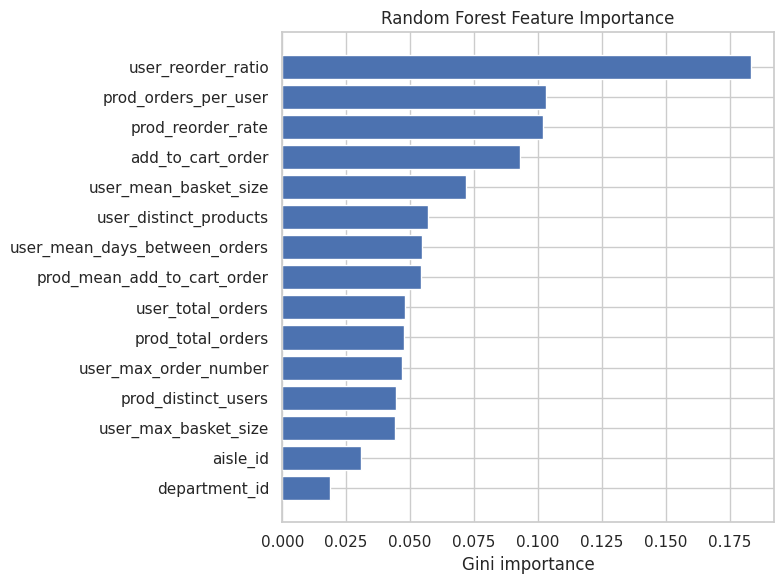

,feature,importance
15,user_reorder_ratio,0.183242
5,prod_orders_per_user,0.103046
3,prod_reorder_rate,0.102003
0,add_to_cart_order,0.093013
12,user_mean_basket_size,0.071850
14,user_distinct_products,0.057173
10,user_mean_days_between_orders,0.054885
4,prod_mean_add_to_cart_order,0.054215
8,user_total_orders,0.047895
1,prod_total_orders,0.047716


In [ ]:
# === STEP 5.1: Global explainability without SHAP ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

feature_names = X_train.columns.tolist()

# 5.1.a: Built-in feature importance from Random Forest
rf_importances = best_model.feature_importances_
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
top_n = 15
plt.barh(fi_df["feature"].head(top_n)[::-1],
         fi_df["importance"].head(top_n)[::-1])
plt.xlabel("Gini importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

fi_df.head(15)

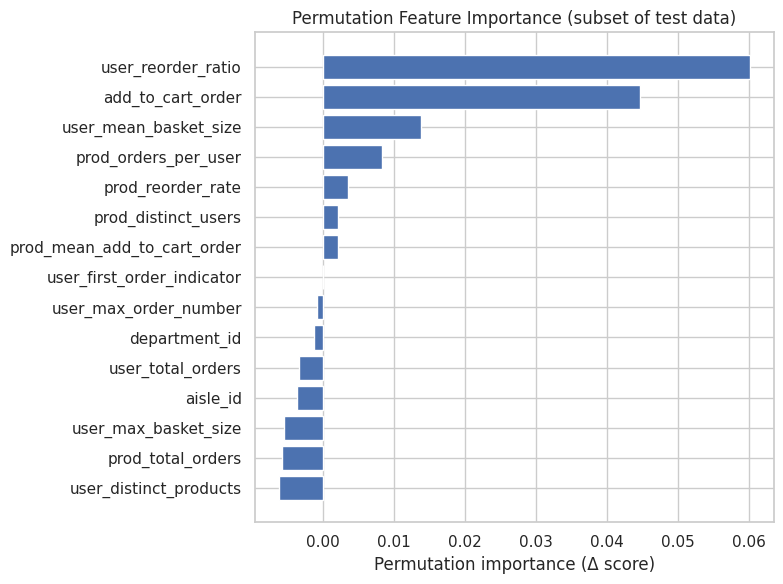

,feature,importance_mean,importance_std
15,user_reorder_ratio,0.0602,0.003763
0,add_to_cart_order,0.0446,0.012175
12,user_mean_basket_size,0.0138,0.006911
5,prod_orders_per_user,0.0084,0.006312
3,prod_reorder_rate,0.0036,0.005238
2,prod_distinct_users,0.0022,0.003124
4,prod_mean_add_to_cart_order,0.0022,0.005492
11,user_first_order_indicator,0.0000,0.000000
9,user_max_order_number,-0.0008,0.005741
7,department_id,-0.0012,0.003059


In [ ]:
# 5.1.b: Permutation importance on a small sample (more reliable, still fast)

from sklearn.utils import resample

# Take a small subset of test data for speed
X_perm, y_perm = resample(
    X_test, y_test,
    n_samples=min(1000, len(X_test)),
    random_state=42,
    stratify=y_test
)

perm_result = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"].head(top_n)[::-1],
         perm_df["importance_mean"].head(top_n)[::-1])
plt.xlabel("Permutation importance (Δ score)")
plt.title("Permutation Feature Importance (subset of test data)")
plt.tight_layout()
plt.show()

perm_df.head(15)

In [ ]:
# === STEP 5.2: Local explanation with LIME (single instance) ===

from lime.lime_tabular import LimeTabularExplainer

class_names = ["No", "Yes"]  # adjust to your target labels

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode='classification'
)

# Choose one example from X_test
row_id = X_test.index[0]   # change index to inspect other examples
x_lime = X_test.loc[row_id].values

lime_exp = lime_explainer.explain_instance(
    data_row=x_lime,
    predict_fn=best_model.predict_proba,
    num_features=10
)

print("LIME explanation (feature, contribution):")
for feat, weight in lime_exp.as_list():
    print(f"{feat}: {weight:.4f}")

LIME explanation (feature, contribution):
add_to_cart_order > 12.00: -0.1432
0.45 < user_reorder_ratio <= 0.61: 0.0450
11.75 < user_mean_basket_size <= 16.50: 0.0205
10.00 < user_total_orders <= 20.00: 0.0135
user_mean_days_between_orders > 16.86: -0.0128
6240.00 < prod_total_orders <= 26721.00: -0.0110
2473.00 < prod_distinct_users <= 9428.00: -0.0106
21.00 < user_max_basket_size <= 29.00: 0.0086
64.00 < user_distinct_products <= 108.00: 0.0067
10.00 < user_max_order_number <= 20.00: 0.0066


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# === STEP 5.3: Local explanation with LIME (single instance) ===

class_names = ["No", "Yes"]   # adjust if your target labels differ

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode='classification'
)

# Reuse the same instance as SHAP (from X_test_sample)
x_lime = x_instance.values[0]

lime_exp = lime_explainer.explain_instance(
    data_row=x_lime,
    predict_fn=best_model.predict_proba,
    num_features=10
)

# Show explanation in text form (safe & light)
print("LIME explanation (feature, contribution):")
for feat, weight in lime_exp.as_list():
    print(f"{feat}: {weight:.4f}")

print("\nStep 5.3 LIME local explanation done.")

LIME explanation (feature, contribution):
add_to_cart_order <= 3.00: 0.1067
user_mean_basket_size <= 8.12: -0.0804
0.45 < user_reorder_ratio <= 0.61: 0.0493
user_max_basket_size <= 14.00: -0.0312
0.49 < prod_reorder_rate <= 0.60: -0.0112
10.00 < user_max_order_number <= 20.00: 0.0058
37.00 < user_distinct_products <= 64.00: -0.0050
7.42 < prod_mean_add_to_cart_order <= 8.62: 0.0047
aisle_id > 107.00: 0.0044
1.98 < prod_orders_per_user <= 2.51: -0.0042

Step 5.3 LIME local explanation done.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# === STEP 5.4: PDP + ICE for key features ===

top_features = [
    "feature_1",
    "feature_2",
    "feature_3"
]  # TODO: replace with real top features

for feat in top_features:
    if feat not in X_test.columns:
        print(f"Skipping {feat}: not found in X_test columns")
        continue

    fig, ax = plt.subplots(figsize=(6, 4))
    PartialDependenceDisplay.from_estimator(
        best_model,
        X_test,
        [feat],
        kind="both",          # PDP + ICE
        ax=ax
    )
    plt.title(f"PDP + ICE for '{feat}'")
    plt.tight_layout()
    plt.show()

print("Step 5.4 PDP + ICE plots done.")

Skipping feature_1: not found in X_test columns
Skipping feature_2: not found in X_test columns
Skipping feature_3: not found in X_test columns
Step 5.4 PDP + ICE plots done.


In [ ]:
# === STEP 5.5: Class imbalance and overfitting check ===

print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

# ROC-AUC and PR-AUC (important if classes are imbalanced)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"\nROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC:  {pr_auc:.3f}")

# Compare train vs test metrics for overfitting
def get_metrics(y_true, y_pred, y_prob=None):
    d = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    if y_prob is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_prob)
    return d

y_train_pred = best_model.predict(X_train)
y_train_proba = best_model.predict_proba(X_train)[:, 1]

train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
test_metrics = get_metrics(y_test, y_pred, y_proba)

print("\nTrain metrics:", train_metrics)
print("Test metrics: ", test_metrics)

print("\nStep 5.5 imbalance + overfitting diagnostics done.")

Train class distribution:
reordered
1    0.598125
0    0.401875
Name: proportion, dtype: float64

Test class distribution:
reordered
1    0.59813
0    0.40187
Name: proportion, dtype: float64

ROC-AUC: 0.795
PR-AUC:  0.847

Train metrics: {'accuracy': 0.8659025, 'precision': 0.9053261415500186, 'recall': 0.8664075235109718, 'f1': 0.88543938148073, 'roc_auc': np.float64(0.9469389538133521)}
Test metrics:  {'accuracy': 0.72607, 'precision': 0.780887194593658, 'recall': 0.7534315282630866, 'f1': 0.7669137105077304, 'roc_auc': np.float64(0.7953880217593138)}

Step 5.5 imbalance + overfitting diagnostics done.


In [ ]:
# === STEP 5.6: Build evaluation DataFrame for bias/fairness audit ===

eval_df = X_test.copy()
eval_df["y_true"] = y_test.values
eval_df["y_pred"] = y_pred
eval_df["y_proba"] = y_proba

print("eval_df shape:", eval_df.shape)
eval_df.head()

eval_df shape: (100000, 19)


,add_to_cart_order,prod_total_orders,prod_distinct_users,prod_reorder_rate,prod_mean_add_to_cart_order,prod_orders_per_user,aisle_id,department_id,user_total_orders,user_max_order_number,user_mean_days_between_orders,user_first_order_indicator,user_mean_basket_size,user_max_basket_size,user_distinct_products,user_reorder_ratio,y_true,y_pred,y_proba
382816,15,13273.0,6127.0,0.538386,7.857154,2.166313,37.0,1.0,12,12,19.083333,1,16.000000,26,99,0.484375,0,1,0.531310
51405,8,10872.0,5127.0,0.528422,8.532837,2.120538,24.0,4.0,3,3,2.333333,1,27.000000,30,41,0.493827,1,1,0.742751
292135,4,890.0,456.0,0.487640,8.962921,1.951754,96.0,20.0,4,4,4.750000,1,18.000000,23,58,0.194444,1,0,0.455484
135973,12,12492.0,6229.0,0.501361,9.400336,2.005458,83.0,4.0,14,14,6.142857,1,8.571429,15,47,0.608333,0,0,0.423544
484286,10,32351.0,14282.0,0.558530,9.853544,2.265159,21.0,16.0,46,46,7.152174,1,12.326087,26,107,0.811287,1,1,0.897475


In [ ]:
# Quick check of available columns for fairness audit
print(eval_df.columns.tolist())

['add_to_cart_order', 'prod_total_orders', 'prod_distinct_users', 'prod_reorder_rate', 'prod_mean_add_to_cart_order', 'prod_orders_per_user', 'aisle_id', 'department_id', 'user_total_orders', 'user_max_order_number', 'user_mean_days_between_orders', 'user_first_order_indicator', 'user_mean_basket_size', 'user_max_basket_size', 'user_distinct_products', 'user_reorder_ratio', 'y_true', 'y_pred', 'y_proba']


In [ ]:
# === STEP 5.7 (UPDATED): Per-group performance & fairness metrics ===

sensitive_col = "user_total_orders"

if sensitive_col not in eval_df.columns:
    raise ValueError(f"{sensitive_col} not found in eval_df columns. "
                     "Replace sensitive_col with an existing column name.")

def group_metrics(df, group_col, positive_label=1):
    rows = []
    for g, sub in df.groupby(group_col):
        y_t = sub["y_true"]
        y_p = sub["y_pred"]
        y_prob = sub["y_proba"]

        tn, fp, fn, tp = confusion_matrix(
            y_t, y_p, labels=[0, positive_label]
        ).ravel()

        acc = accuracy_score(y_t, y_p)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        f1 = f1_score(y_t, y_p, zero_division=0)

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan   # equal opportunity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        pos_rate = (y_p == positive_label).mean()           # demographic parity
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan   # predictive parity

        rows.append({
            group_col: g,
            "n": len(sub),
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "positive_rate": pos_rate,
            "TPR": tpr,
            "FPR": fpr,
            "PPV": ppv,
        })
    return pd.DataFrame(rows)

bias_table = group_metrics(eval_df, sensitive_col)
bias_table

,user_total_orders,n,accuracy,precision,recall,f1,positive_rate,TPR,FPR,PPV
0,3,10765,0.712587,0.712524,0.440553,0.544464,0.241059,0.440553,0.113581,0.712524
1,4,8769,0.696887,0.727846,0.524880,0.609921,0.325579,0.524880,0.161538,0.727846
2,5,7669,0.692137,0.735010,0.572617,0.643730,0.378407,0.572617,0.194980,0.735010
3,6,6680,0.681737,0.729871,0.607837,0.663288,0.429491,0.607837,0.239567,0.729871
4,7,5586,0.696742,0.751061,0.649750,0.696742,0.463838,0.649750,0.248939,0.751061
...,...,...,...,...,...,...,...,...,...,...
92,95,32,0.875000,0.862069,1.000000,0.925926,0.906250,1.000000,0.571429,0.862069
93,96,18,0.833333,0.833333,1.000000,0.909091,1.000000,1.000000,1.000000,0.833333
94,97,28,0.821429,0.807692,1.000000,0.893617,0.928571,1.000000,0.714286,0.807692
95,98,17,0.647059,0.687500,0.916667,0.785714,0.941176,0.916667,1.000000,0.687500


In [ ]:
# === STEP 5.8: Fairness gaps vs majority (reference) group ===

# Reference group = largest group by sample size
ref_group = bias_table.sort_values("n", ascending=False)[sensitive_col].iloc[0]
ref_row = bias_table[bias_table[sensitive_col] == ref_group].iloc[0]

def fairness_diff(row, ref_row, metric):
    return row[metric] - ref_row[metric]

for metric in ["positive_rate", "TPR", "PPV"]:
    col_name = f"{metric}_diff_vs_{ref_group}"
    bias_table[col_name] = bias_table.apply(
        fairness_diff, axis=1, ref_row=ref_row, metric=metric
    )

bias_table

,user_total_orders,n,accuracy,precision,recall,f1,positive_rate,TPR,FPR,PPV,positive_rate_diff_vs_3,TPR_diff_vs_3,PPV_diff_vs_3
0,3,10765,0.712587,0.712524,0.440553,0.544464,0.241059,0.440553,0.113581,0.712524,0.000000,0.000000,0.000000
1,4,8769,0.696887,0.727846,0.524880,0.609921,0.325579,0.524880,0.161538,0.727846,0.084520,0.084327,0.015322
2,5,7669,0.692137,0.735010,0.572617,0.643730,0.378407,0.572617,0.194980,0.735010,0.137348,0.132065,0.022486
3,6,6680,0.681737,0.729871,0.607837,0.663288,0.429491,0.607837,0.239567,0.729871,0.188432,0.167285,0.017347
4,7,5586,0.696742,0.751061,0.649750,0.696742,0.463838,0.649750,0.248939,0.751061,0.222779,0.209197,0.038537
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,95,32,0.875000,0.862069,1.000000,0.925926,0.906250,1.000000,0.571429,0.862069,0.665191,0.559447,0.149545
93,96,18,0.833333,0.833333,1.000000,0.909091,1.000000,1.000000,1.000000,0.833333,0.758941,0.559447,0.120809
94,97,28,0.821429,0.807692,1.000000,0.893617,0.928571,1.000000,0.714286,0.807692,0.687512,0.559447,0.095168
95,98,17,0.647059,0.687500,0.916667,0.785714,0.941176,0.916667,1.000000,0.687500,0.700117,0.476114,-0.025024
